In [39]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

print("Tout fonctionne !")

Tout fonctionne !


In [40]:
import pandas as pd
import numpy as np

# ============================================================
# CHARGEMENT DES DONNÉES BRUTES
# ============================================================

FILE = "Data.xlsx"

print("Chargement de Sheet1 (firmes)...")
static = pd.read_excel(FILE, sheet_name="Sheet1")
static.columns = ["ISIN", "NAME", "Country", "Region"]
static = static.dropna(subset=["ISIN"])
static["ISIN"] = static["ISIN"].astype(str)

# Garder uniquement les firmes européennes
eur_firms = static[static["Region"] == "EUR"]["ISIN"].tolist()
print(f"Nombre de firmes européennes : {len(eur_firms)}")

print("Chargement terminé !")

Chargement de Sheet1 (firmes)...
Nombre de firmes européennes : 633
Chargement terminé !


In [41]:
# ============================================================
# CHARGEMENT DES PRIX MENSUELS (RI_monthly)
# ============================================================

print("Chargement RI_monthly (peut prendre 1-2 minutes)...")
ri_raw = pd.read_excel(FILE, sheet_name="RI_monthly", index_col=1)

# Supprimer la colonne NAME et la ligne parasite
ri_raw = ri_raw.drop(columns=["NAME"], errors="ignore")
ri_raw = ri_raw[ri_raw.index.notna()]
ri_raw = ri_raw[ri_raw.index.astype(str).str.len() > 5]  # enlève la ligne $$ER

# Garder uniquement les firmes européennes
ri_raw = ri_raw.loc[ri_raw.index.isin(eur_firms)]

# Convertir les colonnes en dates
ri_raw.columns = pd.to_datetime(ri_raw.columns, errors="coerce")
ri_raw = ri_raw.loc[:, ri_raw.columns.notna()]
ri_raw = ri_raw.sort_index(axis=1)

# Convertir en numérique
ri_raw = ri_raw.apply(pd.to_numeric, errors="coerce")

print(f"Shape RI_monthly : {ri_raw.shape}")
print(f"Dates : {ri_raw.columns[0]} -> {ri_raw.columns[-1]}")

Chargement RI_monthly (peut prendre 1-2 minutes)...
Shape RI_monthly : (633, 314)
Dates : 1999-12-31 00:00:00 -> 2026-01-30 00:00:00


In [42]:
# ============================================================
# CHARGEMENT MARKET CAP MENSUELLE (MV_monthly)
# ============================================================

print("Chargement MV_monthly...")
mv_raw = pd.read_excel(FILE, sheet_name="MV_monthly", index_col=1)

# Nettoyage
mv_raw = mv_raw.drop(columns=["NAME"], errors="ignore")
mv_raw = mv_raw[mv_raw.index.notna()]
mv_raw = mv_raw[mv_raw.index.astype(str).str.len() > 5]

# Garder uniquement les firmes européennes
mv_raw = mv_raw.loc[mv_raw.index.isin(eur_firms)]

# Convertir les colonnes en dates
mv_raw.columns = pd.to_datetime(mv_raw.columns, errors="coerce")
mv_raw = mv_raw.loc[:, mv_raw.columns.notna()]
mv_raw = mv_raw.sort_index(axis=1)

# Convertir en numérique
mv_raw = mv_raw.apply(pd.to_numeric, errors="coerce")

print(f"Shape MV_monthly : {mv_raw.shape}")
print(f"Dates : {mv_raw.columns[0]} -> {mv_raw.columns[-1]}")

Chargement MV_monthly...
Shape MV_monthly : (633, 314)
Dates : 1999-12-31 00:00:00 -> 2026-01-30 00:00:00


In [43]:
# ============================================================
# CHARGEMENT SCOPE 1, SCOPE 2 ET REVENUES (annuel)
# ============================================================

print("Chargement Scope1...")
scope1_raw = pd.read_excel(FILE, sheet_name="Scope1", index_col=1)
scope1_raw = scope1_raw.drop(columns=["NAME"], errors="ignore")
scope1_raw = scope1_raw[scope1_raw.index.notna()]
scope1_raw = scope1_raw[scope1_raw.index.astype(str).str.len() > 5]
scope1_raw = scope1_raw.loc[scope1_raw.index.isin(eur_firms)]
scope1_raw.columns = [int(c) for c in scope1_raw.columns if str(c).isdigit()]
scope1_raw = scope1_raw.apply(pd.to_numeric, errors="coerce")

print("Chargement Scope2...")
scope2_raw = pd.read_excel(FILE, sheet_name="Scope2", index_col=1)
scope2_raw = scope2_raw.drop(columns=["NAME"], errors="ignore")
scope2_raw = scope2_raw[scope2_raw.index.notna()]
scope2_raw = scope2_raw[scope2_raw.index.astype(str).str.len() > 5]
scope2_raw = scope2_raw.loc[scope2_raw.index.isin(eur_firms)]
scope2_raw.columns = [int(c) for c in scope2_raw.columns if str(c).isdigit()]
scope2_raw = scope2_raw.apply(pd.to_numeric, errors="coerce")

print("Chargement Revenues...")
rev_raw = pd.read_excel(FILE, sheet_name="REV", index_col=1)
rev_raw = rev_raw.drop(columns=["NAME"], errors="ignore")
rev_raw = rev_raw[rev_raw.index.notna()]
rev_raw = rev_raw[rev_raw.index.astype(str).str.len() > 5]
rev_raw = rev_raw.loc[rev_raw.index.isin(eur_firms)]
rev_raw.columns = [int(c) for c in rev_raw.columns if str(c).isdigit()]
rev_raw = rev_raw.apply(pd.to_numeric, errors="coerce")

print(f"Scope1 shape : {scope1_raw.shape}")
print(f"Scope2 shape : {scope2_raw.shape}")
print(f"Revenues shape : {rev_raw.shape}")
print("Chargement terminé !")

Chargement Scope1...
Chargement Scope2...
Chargement Revenues...
Scope1 shape : (633, 27)
Scope2 shape : (633, 27)
Revenues shape : (633, 27)
Chargement terminé !


In [44]:
# ============================================================
# NETTOYAGE DES PRIX ET CONSTRUCTION DES RETOURS
# ============================================================

# Traiter RI < 0.5 comme manquant
prices_m = ri_raw.copy()
prices_m[prices_m < 0.5] = np.nan

# Construire les retours simples avec gestion du delisting
def build_returns(prices):
    arr = prices.to_numpy(dtype=float)
    n_assets, n_months = arr.shape
    rets = np.full((n_assets, n_months), np.nan, dtype=float)

    for i in range(n_assets):
        p = arr[i]
        observed = np.isfinite(p)
        for t in range(1, n_months):
            if observed[t-1] and observed[t]:
                rets[i, t] = (p[t] / p[t-1]) - 1.0
            elif observed[t-1] and not observed[t]:
                # Delisting : prix disparaît définitivement
                if np.all(~observed[t:]):
                    rets[i, t] = -1.0

    return pd.DataFrame(rets, index=prices.index, columns=prices.columns)

print("Construction des retours mensuels...")
returns_m = build_returns(prices_m)
print(f"Shape retours : {returns_m.shape}")
print("Fait !")

Construction des retours mensuels...
Shape retours : (633, 314)
Fait !


In [45]:
# ============================================================
# NETTOYAGE DONNÉES CARBONE ET CARBON INTENSITY
# ============================================================

# Total emissions = Scope1 + Scope2
emissions_y = scope1_raw.add(scope2_raw, fill_value=np.nan)

# Forward fill : utiliser l'année précédente si manquant
# (uniquement après la première valeur disponible)
emissions_y = emissions_y.ffill(axis=1)
rev_clean = rev_raw.ffill(axis=1)

# Carbon Intensity = emissions (tonnes) / revenue (millions USD)
# Revenue est en milliers USD donc on divise par 1000
rev_millions = rev_clean / 1000.0

# CI en tonnes CO2 par million USD de revenue
carbon_intensity_y = emissions_y / rev_millions

print(f"Shape emissions : {emissions_y.shape}")
print(f"Shape carbon intensity : {carbon_intensity_y.shape}")

# Vérification rapide
print(f"\nNombre de firmes avec CI disponible en 2013 : {carbon_intensity_y[2013].notna().sum()}")
print(f"Nombre de firmes avec CI disponible en 2020 : {carbon_intensity_y[2020].notna().sum()}")
print("Fait !")

Shape emissions : (633, 27)
Shape carbon intensity : (633, 27)

Nombre de firmes avec CI disponible en 2013 : 472
Nombre de firmes avec CI disponible en 2020 : 599
Fait !


In [46]:
# ============================================================
# PARAMÈTRES
# ============================================================

START_REBAL_YEAR = 2013
END_REBAL_YEAR = 2024
ESTIMATION_MONTHS = 120
MIN_MONTHLY_OBS = 36
STALE_THRESHOLD = 0.5

# ============================================================
# FONCTIONS UTILITAIRES
# ============================================================

def get_december(year, columns):
    candidates = columns[(columns.year == year) & (columns.month == 12)]
    if len(candidates) == 0:
        raise ValueError(f"Pas de décembre pour {year}")
    return candidates.max()

def build_investment_set(returns_m, prices_m, carbon_intensity_y, year):
    all_months = returns_m.columns
    dec_y = get_december(year, all_months)
    end_pos = all_months.get_loc(dec_y)
    start_pos = end_pos - ESTIMATION_MONTHS + 1

    window = returns_m.iloc[:, start_pos:end_pos+1]

    # Critère 1 : assez d'observations
    n_obs = window.notna().sum(axis=1)
    enough_obs = n_obs >= MIN_MONTHLY_OBS

    # Critère 2 : pas de stale prices
    zero_share = window.eq(0).sum(axis=1) / n_obs.replace(0, np.nan)
    not_stale = zero_share <= STALE_THRESHOLD

    # Critère 3 : carbon intensity disponible
    if year in carbon_intensity_y.columns:
        has_carbon = carbon_intensity_y[year].notna()
    else:
        has_carbon = pd.Series(False, index=returns_m.index)

    # Critère 4 : prix disponible en décembre Y
    has_price = prices_m[dec_y].notna()

    eligible = enough_obs & not_stale & has_carbon & has_price
    return eligible[eligible].index.tolist()

def min_var_weights(cov):
    n = cov.shape[0]
    w0 = np.repeat(1.0/n, n)
    cov = np.nan_to_num(cov, nan=0.0)
    cov = 0.5 * (cov + cov.T)
    trace = np.trace(cov)
    ridge = (1e-10 * trace / n) if trace != 0 else 1e-10
    cov = cov + ridge * np.eye(n)
    scale = np.nanmax(np.abs(cov))
    if scale > 0:
        cov = cov / scale

    res = minimize(
        lambda w: float(w @ cov @ w),
        x0=w0,
        jac=lambda w: 2.0 * (cov @ w),
        method="SLSQP",
        bounds=[(0.0, 1.0)]*n,
        constraints=[{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}],
        options={"maxiter": 300, "ftol": 1e-6}
    )
    return res.x if res.success else w0

# Test rapide
investable_2013 = build_investment_set(returns_m, prices_m, carbon_intensity_y, 2013)
print(f"Firmes investissables en 2013 : {len(investable_2013)}")

Firmes investissables en 2013 : 469


In [47]:
# ============================================================
# BOUCLE PRINCIPALE - PARTIE I
# ============================================================

mv_m = mv_raw.copy()

def compute_monthly_returns(returns_m, mv_m, year, isins, w_mv_start):
    months_next = returns_m.columns[returns_m.columns.year == (year+1)]
    months_next = months_next.sort_values()

    rp_mv = {}
    rp_vw = {}
    w_mv = pd.Series(w_mv_start, index=isins, dtype=float)

    for m in months_next:
        r = returns_m.loc[isins, m].copy()

        # Retour min variance
        valid = r.notna() & (w_mv > 0)
        if valid.any():
            w_eff = w_mv[valid] / w_mv[valid].sum()
            rp_m = float((w_eff * r[valid]).sum())
        else:
            rp_m = np.nan
        rp_mv[m] = rp_m

        # Drift des poids
        if np.isfinite(rp_m) and (1.0 + rp_m) != 0:
            gross = 1.0 + r[valid]
            w_mv.loc[:] = 0.0
            w_mv.loc[w_eff.index] = w_eff * gross / (1.0 + rp_m)

        # Retour value-weighted
        prev_months = returns_m.columns[returns_m.columns < m]
        if len(prev_months) == 0:
            rp_vw[m] = np.nan
            continue
        prev_m = prev_months.max()
        caps = mv_m.loc[isins, prev_m]
        valid_caps = caps.notna() & (caps > 0)
        if valid_caps.any():
            w_vw = caps[valid_caps] / caps[valid_caps].sum()
            valid_r = r[valid_caps].notna()
            if valid_r.any():
                rp_vw[m] = float((w_vw[valid_r] * r[valid_caps][valid_r]).sum())
            else:
                rp_vw[m] = np.nan
        else:
            rp_vw[m] = np.nan

    return pd.Series(rp_mv), pd.Series(rp_vw)

# Boucle sur toutes les années
print("Lancement de la boucle principale...")
all_mv = []
all_vw = []
weights_dict = {}

for y in range(START_REBAL_YEAR, END_REBAL_YEAR + 1):
    investable = build_investment_set(returns_m, prices_m, carbon_intensity_y, y)
    print(f"  {y} : {len(investable)} firmes investissables")

    dec_y = get_december(y, returns_m.columns)
    end_pos = returns_m.columns.get_loc(dec_y)
    start_pos = end_pos - ESTIMATION_MONTHS + 1

    window = returns_m.loc[investable, returns_m.columns[start_pos:end_pos+1]].T
    window = window.replace([np.inf, -np.inf], np.nan)
    cov = window.cov(ddof=0).to_numpy()

    w_mv = min_var_weights(cov)
    weights_dict[y] = pd.Series(w_mv, index=investable)

    rp_mv, rp_vw = compute_monthly_returns(returns_m, mv_m, y, investable, w_mv)
    all_mv.append(rp_mv)
    all_vw.append(rp_vw)

# Combiner les retours
r_mv = pd.concat(all_mv).sort_index()
r_vw = pd.concat(all_vw).sort_index()

# Filtrer 2014-2025
r_mv = r_mv.loc["2014-01-31":"2025-12-31"]
r_vw = r_vw.loc["2014-01-31":"2025-12-31"]

print(f"\nNombre de mois : {len(r_mv)}")
print("Boucle terminée !")

Lancement de la boucle principale...
  2013 : 469 firmes investissables
  2014 : 487 firmes investissables
  2015 : 505 firmes investissables
  2016 : 511 firmes investissables
  2017 : 524 firmes investissables
  2018 : 545 firmes investissables
  2019 : 572 firmes investissables
  2020 : 591 firmes investissables
  2021 : 600 firmes investissables
  2022 : 590 firmes investissables
  2023 : 575 firmes investissables
  2024 : 563 firmes investissables

Nombre de mois : 144
Boucle terminée !


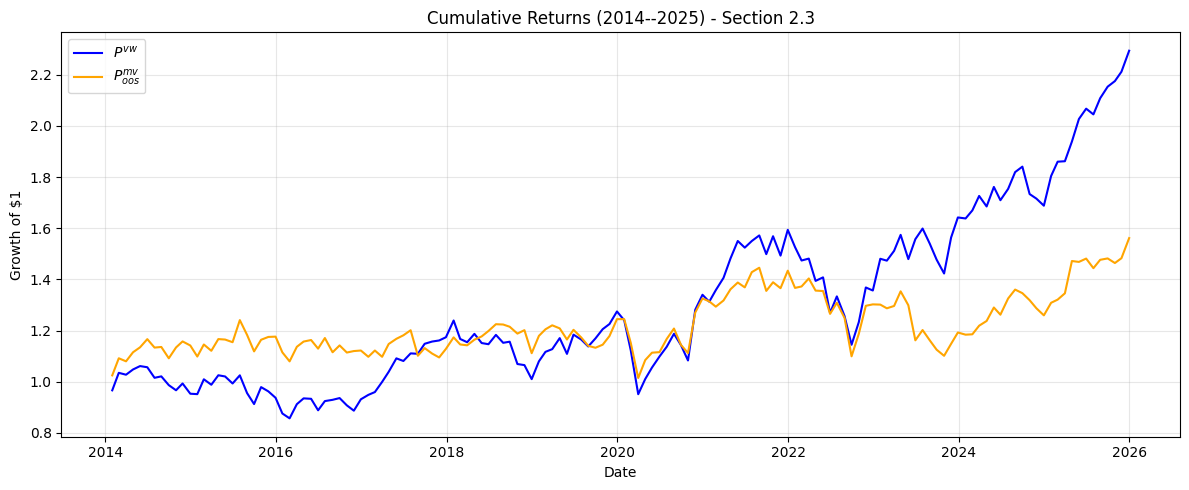

Plot saved!


In [61]:
# ============================================================
# SECTION 2.3 - Cumulative Returns Plot 
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

cum_mv = (1 + r_mv).cumprod()
cum_vw = (1 + r_vw).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_vw.index, cum_vw, label="$P^{vw}$",          color="blue")
ax.plot(cum_mv.index, cum_mv, label="$P^{mv}_{oos}$",    color="orange")
ax.set_title("Cumulative Returns (2014--2025) - Section 2.3")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig("plot_section23.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved!")

In [48]:
# ============================================================
# STATISTIQUES - VÉRIFICATION VS EXCEL
# ============================================================

def annualized_stats(r):
    r = r.dropna()
    T = len(r)
    ann_return = r.mean() * 12
    ann_vol = r.std(ddof=0) * np.sqrt(12)
    ann_cum_return = (1 + r).prod() ** (12/T) - 1
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan
    return {
        "Annualized return": ann_return,
        "Annualized volatility": ann_vol,
        "Annualized cumulative return": ann_cum_return,
        "Sharpe ratio": sharpe,
        "Minimum monthly return": r.min(),
        "Maximum monthly return": r.max(),
    }

stats = pd.DataFrame({
    "Value-weighted": annualized_stats(r_vw),
    "Min variance": annualized_stats(r_mv),
})

print(stats.round(4))

                              Value-weighted  Min variance
Annualized return                     0.0819        0.0467
Annualized volatility                 0.1581        0.1377
Annualized cumulative return          0.0716        0.0378
Sharpe ratio                          0.5178        0.3393
Minimum monthly return               -0.1530       -0.1200
Maximum monthly return                0.1828        0.1424


# Part II - Portfolio Allocation with Carbon Emission Reduction

In [49]:
# =============================================================
# Section 3.1 - Carbon Emissions
# Compute carbon intensity, WACI and carbon footprint
# for the minimum variance and value-weighted portfolios.
# Starting wealth: V_2013 = 1,000,000 USD
# =============================================================

V0 = 1_000_000  # starting wealth in USD

# --- Carbon Intensity ---
# CI_i,Y = E_i,Y / Rev_i,Y (tonnes CO2 / million USD revenue)
# Revenue is in thousands USD -> divide by 1000
emissions = (scope1_raw + scope2_raw).ffill(axis=1)
rev_m = (rev_raw / 1000.0).ffill(axis=1)
CI = emissions / rev_m

# --- Portfolio value evolution ---
# V_Y = V_0 * cumulative product of annual portfolio returns
# We use December monthly returns to get annual returns
def get_annual_return(r_monthly, year):
    months = r_monthly[r_monthly.index.year == year]
    return float((1 + months).prod() - 1)

# Compute V_Y for min variance portfolio
V_mv = {}
V_mv[2013] = V0
for y in range(2014, 2025):
    ann_ret = get_annual_return(r_mv, y)
    V_mv[y] = V_mv[y-1] * (1 + ann_ret)
V_mv = pd.Series(V_mv)

# Compute V_Y for value-weighted portfolio
V_vw = {}
V_vw[2013] = V0
for y in range(2014, 2025):
    ann_ret = get_annual_return(r_vw, y)
    V_vw[y] = V_vw[y-1] * (1 + ann_ret)
V_vw = pd.Series(V_vw)

# --- WACI and Carbon Footprint ---
# WACI_Y = sum(alpha_i * CI_i,Y)
# CF_Y = (1/V_Y) * sum(alpha_i * V_Y * E_i,Y / Cap_i,Y)
#       = sum(alpha_i * E_i,Y / Cap_i,Y)
# Note: V_Y cancels out in CF formula

mv_annual_clean = mv_annual.ffill(axis=1)

waci_mv_dict, cf_mv_dict = {}, {}
waci_vw_dict, cf_vw_dict = {}, {}

for y in range(START_REBAL_YEAR, END_REBAL_YEAR + 1):
    investable = list(weights_dict[y].index)
    w = weights_dict[y]

    ci_y  = CI.loc[investable, y] if y in CI.columns else pd.Series(np.nan, index=investable)
    em_y  = emissions.loc[investable, y] if y in emissions.columns else pd.Series(np.nan, index=investable)
    cap_y = mv_annual_clean.loc[investable, y] if y in mv_annual_clean.columns else pd.Series(np.nan, index=investable)

    # WACI min variance
    valid_ci = ci_y.notna()
    waci_mv_dict[y] = float((w[valid_ci] * ci_y[valid_ci]).sum()) if valid_ci.any() else np.nan

    # CF min variance: CF = sum(alpha_i * E_i / Cap_i)
    valid_cf = em_y.notna() & cap_y.notna() & (cap_y > 0)
    cf_mv_dict[y] = float((w[valid_cf] * em_y[valid_cf] / cap_y[valid_cf]).sum()) if valid_cf.any() else np.nan

    # Value-weighted
    total_cap = cap_y[cap_y > 0].sum()
    if total_cap > 0:
        w_vw = cap_y / total_cap
        w_vw = w_vw.fillna(0)

        # WACI value-weighted
        waci_vw_dict[y] = float((w_vw[valid_ci] * ci_y[valid_ci]).sum()) if valid_ci.any() else np.nan

        # CF value-weighted = sum(E_i) / Cap_total
        valid_em = em_y.notna()
        cf_vw_dict[y] = float(em_y[valid_em].sum() / total_cap) if valid_em.any() else np.nan
    else:
        waci_vw_dict[y] = np.nan
        cf_vw_dict[y]   = np.nan

waci_mv = pd.Series(waci_mv_dict)
waci_vw = pd.Series(waci_vw_dict)
cf_mv   = pd.Series(cf_mv_dict)
cf_vw   = pd.Series(cf_vw_dict)

print("WACI and Carbon Footprint - Min Variance vs Value-Weighted:")
summary_31 = pd.DataFrame({
    "WACI MV":  waci_mv.round(2),
    "WACI VW":  waci_vw.round(2),
    "CF MV":    cf_mv.round(4),
    "CF VW":    cf_vw.round(4),
})
print(summary_31)

WACI and Carbon Footprint - Min Variance vs Value-Weighted:
      WACI MV  WACI VW      CF MV     CF VW
2013    63.48   136.10    26.0089  214.2432
2014   124.96   127.42   699.9289  185.8266
2015   383.59   157.02  1091.1689  196.1872
2016   298.80   151.50  1884.7019  209.4409
2017   366.83   171.48   566.4743  185.1963
2018   124.15   134.88   161.3836  143.6106
2019    85.67   139.05    39.7018  153.2836
2020   142.85   132.01    57.1703  124.9838
2021   131.30   133.82    39.3965  117.4956
2022    52.59   106.60    49.3010   98.6566
2023    40.78    79.71   115.4756   96.1036
2024    38.29    83.27    62.6149   89.5039


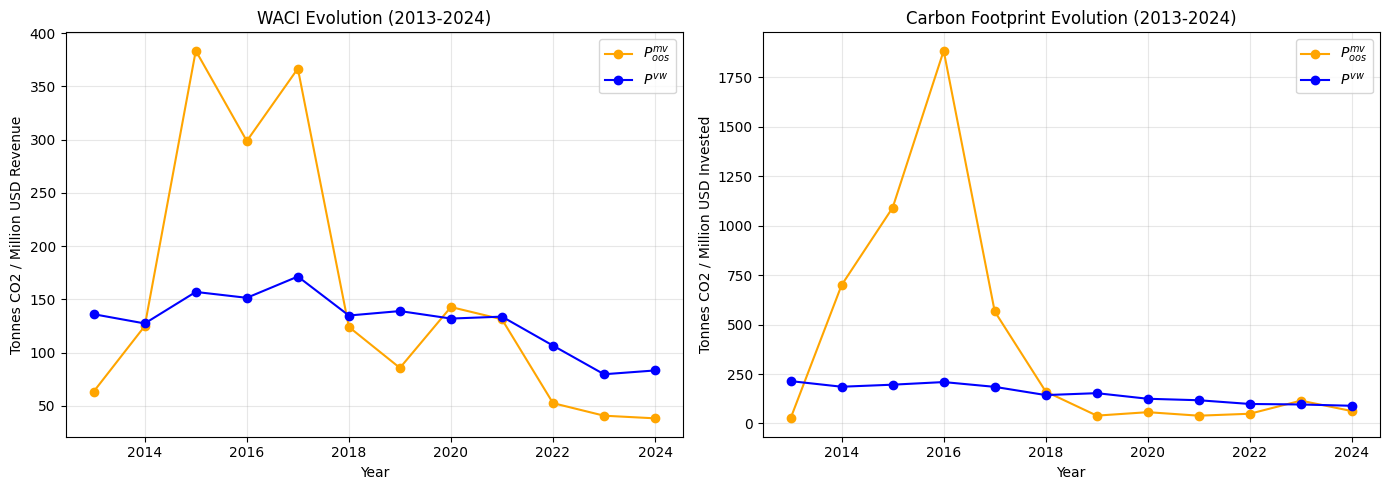

Plot saved!


In [50]:
# WACI and CF plots for P_mv and P_vw

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# WACI
axes[0].plot(waci_mv.index, waci_mv, label="$P^{mv}_{oos}$", color="orange", marker="o")
axes[0].plot(waci_vw.index, waci_vw, label="$P^{vw}$",       color="blue",   marker="o")
axes[0].set_title("WACI Evolution (2013-2024)")
axes[0].set_ylabel("Tonnes CO2 / Million USD Revenue")
axes[0].set_xlabel("Year")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CF
axes[1].plot(cf_mv.index, cf_mv, label="$P^{mv}_{oos}$", color="orange", marker="o")
axes[1].plot(cf_vw.index, cf_vw, label="$P^{vw}$",       color="blue",   marker="o")
axes[1].set_title("Carbon Footprint Evolution (2013-2024)")
axes[1].set_ylabel("Tonnes CO2 / Million USD Invested")
axes[1].set_xlabel("Year")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot_section31.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved!")

In [51]:
# Top 10 firms contributing most to WACI of the value-weighted portfolio (2013)

y = 2013
investable = list(weights_dict[y].index)
cap_y = mv_annual_clean.loc[investable, y]
total_cap = cap_y.sum()
w_vw = cap_y / total_cap
ci_y = CI.loc[investable, y]

# WACI contribution = w_vw_i * CI_i
waci_contrib = (w_vw * ci_y).dropna().sort_values(ascending=False).head(10)

top10 = static[static["ISIN"].isin(waci_contrib.index)][["ISIN", "NAME"]].set_index("ISIN")
top10["Weight VW (%)"]      = (w_vw[waci_contrib.index] * 100).round(2)
top10["Carbon Intensity"]   = ci_y[waci_contrib.index].round(2)
top10["WACI Contribution"]  = waci_contrib.round(2)

print("Top 10 firms driving WACI - Value-Weighted portfolio (2013):")
print(top10.to_string())

Top 10 firms driving WACI - Value-Weighted portfolio (2013):
                                                      NAME  Weight VW (%)  Carbon Intensity  WACI Contribution
ISIN                                                                                                          
CH0012214059                                        HOLCIM           0.32           4279.06              13.70
DE0006047004                          HEIDELBERG MATERIALS           0.15           3082.97               4.65
DE0007037129                                           RWE           0.27           2405.93               6.52
ES0130670112                                        ENDESA           0.31           1266.34               3.93
FI0009007132                                        FORTUM           0.21           2491.25               5.26
FR0000120073  L AIR LQE.SC.ANYME. POUR L ETUDE ET L EPXTN.           0.51           1036.68               5.28
FR0010242511                    EDF DEAD - DELIST.0

In [52]:
# Section 3.2 - P_mv_oos(0.5)
# Minimize portfolio variance subject to CF <= 0.5 * CF(P_mv_oos)
# Long-only constraint, weights sum to 1

def min_var_carbon_constraint(cov, cf_target, em_y, cap_y):
    """Minimize variance with CF constraint."""
    n = cov.shape[0]
    w0 = np.repeat(1.0/n, n)

    cov = np.nan_to_num(cov, nan=0.0)
    cov = 0.5 * (cov + cov.T)
    trace = np.trace(cov)
    ridge = (1e-10 * trace / n) if trace != 0 else 1e-10
    cov = cov + ridge * np.eye(n)
    scale = np.nanmax(np.abs(cov))
    if scale > 0:
        cov = cov / scale

    cf_unit = (em_y / cap_y).fillna(0).values

    constraints = [
        {"type": "eq",  "fun": lambda w: np.sum(w) - 1.0},
        {"type": "ineq","fun": lambda w: cf_target - float(w @ cf_unit)},
    ]

    res = minimize(
        lambda w: float(w @ cov @ w),
        x0=w0,
        jac=lambda w: 2.0 * (cov @ w),
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n,
        constraints=constraints,
        options={"maxiter": 500, "ftol": 1e-8}
    )

    if res.success and np.all(np.isfinite(res.x)):
        return res.x
    else:
        print(f"  Infeasible constraint - returning unconstrained MV weights")
        return min_var_weights(cov)

print("Computing P_mv_oos(0.5)...")
all_mv05, weights_mv05_dict = [], {}

for y in range(START_REBAL_YEAR, END_REBAL_YEAR + 1):
    investable = list(weights_dict[y].index)
    em_y  = emissions.loc[investable, y] if y in emissions.columns else pd.Series(np.nan, index=investable)
    cap_y = mv_annual_clean.loc[investable, y] if y in mv_annual_clean.columns else pd.Series(np.nan, index=investable)

    valid = em_y.notna() & cap_y.notna() & (cap_y > 0)
    inv_valid = [i for i in investable if valid[i]]

    em_v, cap_v = em_y[inv_valid], cap_y[inv_valid]
    cf_target = 0.5 * cf_mv[y]

    dec_y   = get_december(y, returns_m.columns)
    end_pos = returns_m.columns.get_loc(dec_y)
    start_pos = end_pos - ESTIMATION_MONTHS + 1
    window = returns_m.loc[inv_valid, returns_m.columns[start_pos:end_pos+1]].T
    window = window.replace([np.inf, -np.inf], np.nan)
    cov = window.cov(ddof=0).to_numpy()

    w = min_var_carbon_constraint(cov, cf_target, em_v, cap_v)
    weights_mv05_dict[y] = pd.Series(w, index=inv_valid)

    rp, _ = compute_monthly_returns(returns_m, mv_m, y, inv_valid, w)
    all_mv05.append(rp)
    print(f"  {y}: CF_target={cf_target:.4f}, firms={len(inv_valid)}")

r_mv05 = pd.concat(all_mv05).sort_index().loc["2014-01-31":"2025-12-31"]

print("\nSummary statistics - P_mv vs P_mv(0.5):")
stats_32 = pd.DataFrame({
    "P_mv_oos":      annualized_stats(r_mv),
    "P_mv_oos(0.5)": annualized_stats(r_mv05),
})
print(stats_32.round(4))

Computing P_mv_oos(0.5)...
  2013: CF_target=13.0044, firms=469
  2014: CF_target=349.9644, firms=487
  2015: CF_target=545.5845, firms=505
  2016: CF_target=942.3510, firms=511
  2017: CF_target=283.2371, firms=524
  2018: CF_target=80.6918, firms=545
  2019: CF_target=19.8509, firms=572
  2020: CF_target=28.5852, firms=591
  2021: CF_target=19.6982, firms=600
  2022: CF_target=24.6505, firms=590
  2023: CF_target=57.7378, firms=575
  2024: CF_target=31.3074, firms=563

Summary statistics - P_mv vs P_mv(0.5):
                              P_mv_oos  P_mv_oos(0.5)
Annualized return               0.0467         0.0532
Annualized volatility           0.1377         0.1356
Annualized cumulative return    0.0378         0.0449
Sharpe ratio                    0.3393         0.3926
Minimum monthly return         -0.1200        -0.1143
Maximum monthly return          0.1424         0.1356


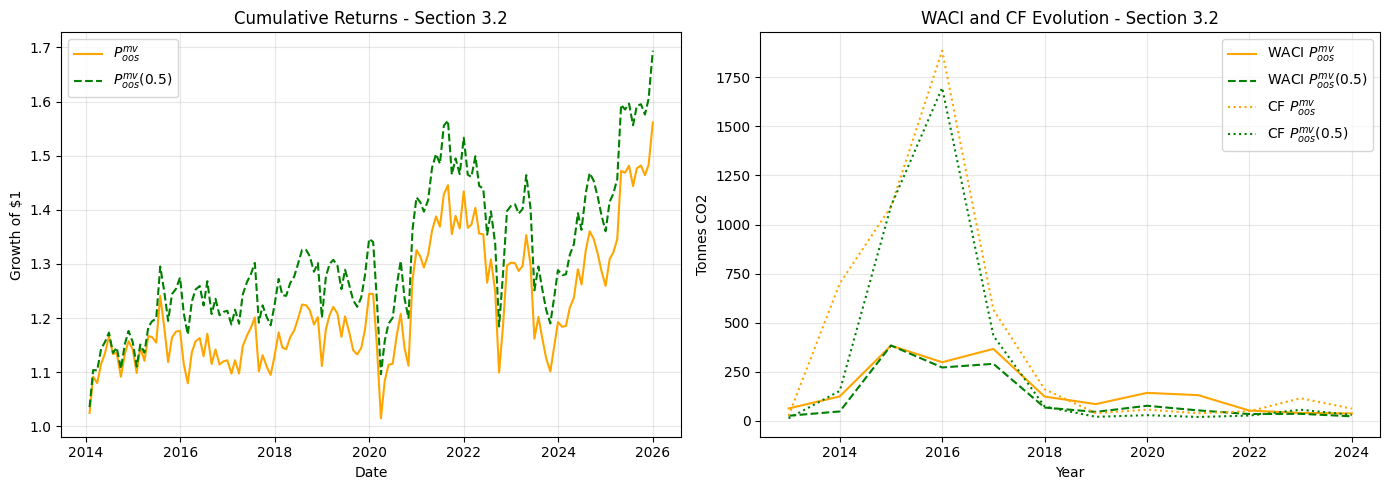

Plot saved!


In [53]:
# WACI and CF for P_mv_oos(0.5)

waci_mv05_dict, cf_mv05_dict = {}, {}

for y in range(START_REBAL_YEAR, END_REBAL_YEAR + 1):
    w = weights_mv05_dict[y]
    investable = w.index.tolist()

    ci_y  = CI.loc[investable, y] if y in CI.columns else pd.Series(np.nan, index=investable)
    em_y  = emissions.loc[investable, y] if y in emissions.columns else pd.Series(np.nan, index=investable)
    cap_y = mv_annual_clean.loc[investable, y] if y in mv_annual_clean.columns else pd.Series(np.nan, index=investable)

    valid_ci = ci_y.notna()
    waci_mv05_dict[y] = float((w[valid_ci] * ci_y[valid_ci]).sum()) if valid_ci.any() else np.nan

    valid_cf = em_y.notna() & cap_y.notna() & (cap_y > 0)
    cf_mv05_dict[y] = float((w[valid_cf] * em_y[valid_cf] / cap_y[valid_cf]).sum()) if valid_cf.any() else np.nan

waci_mv05 = pd.Series(waci_mv05_dict)
cf_mv05   = pd.Series(cf_mv05_dict)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative returns
cum_mv   = (1 + r_mv).cumprod()
cum_mv05 = (1 + r_mv05).cumprod()

axes[0].plot(cum_mv.index,   cum_mv,   label="$P^{mv}_{oos}$",      color="orange")
axes[0].plot(cum_mv05.index, cum_mv05, label="$P^{mv}_{oos}(0.5)$", color="green", linestyle="--")
axes[0].set_title("Cumulative Returns - Section 3.2")
axes[0].set_ylabel("Growth of $1")
axes[0].set_xlabel("Date")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# WACI and CF evolution
axes[1].plot(waci_mv.index,   waci_mv,   label="WACI $P^{mv}_{oos}$",      color="orange")
axes[1].plot(waci_mv05.index, waci_mv05, label="WACI $P^{mv}_{oos}(0.5)$", color="green", linestyle="--")
axes[1].plot(cf_mv.index,     cf_mv,     label="CF $P^{mv}_{oos}$",        color="orange", linestyle=":")
axes[1].plot(cf_mv05.index,   cf_mv05,   label="CF $P^{mv}_{oos}(0.5)$",   color="green",  linestyle=":")
axes[1].set_title("WACI and CF Evolution - Section 3.2")
axes[1].set_ylabel("Tonnes CO2")
axes[1].set_xlabel("Year")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot_section32.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved!")

In [54]:
# Section 3.3 - P_vw_oos(0.5)
# Minimize tracking error vs value-weighted portfolio
# subject to CF <= 0.5 * CF(P_vw)

def tracking_error_carbon_constraint(cov, w_vw, cf_target, em_y, cap_y):
    """Minimize tracking error vs VW with CF constraint."""
    n = len(w_vw)

    cov = np.nan_to_num(cov, nan=0.0)
    cov = 0.5 * (cov + cov.T)
    trace = np.trace(cov)
    ridge = (1e-10 * trace / n) if trace != 0 else 1e-10
    cov = cov + ridge * np.eye(n)
    scale = np.nanmax(np.abs(cov))
    if scale > 0:
        cov = cov / scale

    cf_unit = (em_y / cap_y).fillna(0).values

    constraints = [
        {"type": "eq",  "fun": lambda w: np.sum(w) - 1.0},
        {"type": "ineq","fun": lambda w: cf_target - float(w @ cf_unit)},
    ]

    res = minimize(
        lambda w: float((w - w_vw) @ cov @ (w - w_vw)),
        x0=w_vw.copy(),
        jac=lambda w: 2.0 * (cov @ (w - w_vw)),
        method="SLSQP",
        bounds=[(0.0, 1.0)] * n,
        constraints=constraints,
        options={"maxiter": 500, "ftol": 1e-8}
    )

    if res.success and np.all(np.isfinite(res.x)):
        return res.x
    else:
        print(f"  Infeasible constraint - returning VW weights")
        return w_vw.copy()

print("Computing P_vw_oos(0.5)...")
all_vw05, weights_vw05_dict = [], {}

for y in range(START_REBAL_YEAR, END_REBAL_YEAR + 1):
    investable = list(weights_dict[y].index)
    em_y  = emissions.loc[investable, y] if y in emissions.columns else pd.Series(np.nan, index=investable)
    cap_y = mv_annual_clean.loc[investable, y] if y in mv_annual_clean.columns else pd.Series(np.nan, index=investable)

    valid = em_y.notna() & cap_y.notna() & (cap_y > 0)
    inv_valid = [i for i in investable if valid[i]]

    em_v, cap_v = em_y[inv_valid], cap_y[inv_valid]
    total_cap = cap_v.sum()
    w_vw_arr = (cap_v / total_cap).values
    cf_target = 0.5 * cf_vw[y]

    dec_y     = get_december(y, returns_m.columns)
    end_pos   = returns_m.columns.get_loc(dec_y)
    start_pos = end_pos - ESTIMATION_MONTHS + 1
    window    = returns_m.loc[inv_valid, returns_m.columns[start_pos:end_pos+1]].T
    window    = window.replace([np.inf, -np.inf], np.nan)
    cov       = window.cov(ddof=0).to_numpy()

    w = tracking_error_carbon_constraint(cov, w_vw_arr, cf_target, em_v, cap_v)
    weights_vw05_dict[y] = pd.Series(w, index=inv_valid)

    rp, _ = compute_monthly_returns(returns_m, mv_m, y, inv_valid, w)
    all_vw05.append(rp)
    print(f"  {y}: CF_target={cf_target:.4f}, firms={len(inv_valid)}")

r_vw05 = pd.concat(all_vw05).sort_index().loc["2014-01-31":"2025-12-31"]

print("\nSummary statistics - P_vw vs P_vw(0.5):")
stats_33 = pd.DataFrame({
    "P_vw":       annualized_stats(r_vw),
    "P_vw(0.5)":  annualized_stats(r_vw05),
})
print(stats_33.round(4))

Computing P_vw_oos(0.5)...
  2013: CF_target=107.1216, firms=469
  2014: CF_target=92.9133, firms=487
  2015: CF_target=98.0936, firms=505
  2016: CF_target=104.7205, firms=511
  2017: CF_target=92.5982, firms=524
  2018: CF_target=71.8053, firms=545
  2019: CF_target=76.6418, firms=572
  2020: CF_target=62.4919, firms=591
  2021: CF_target=58.7478, firms=600
  2022: CF_target=49.3283, firms=590
  2023: CF_target=48.0518, firms=575
  2024: CF_target=44.7520, firms=563

Summary statistics - P_vw vs P_vw(0.5):
                                P_vw  P_vw(0.5)
Annualized return             0.0819     0.0651
Annualized volatility         0.1581     0.1645
Annualized cumulative return  0.0716     0.0527
Sharpe ratio                  0.5178     0.3957
Minimum monthly return       -0.1530    -0.1785
Maximum monthly return        0.1828     0.1784


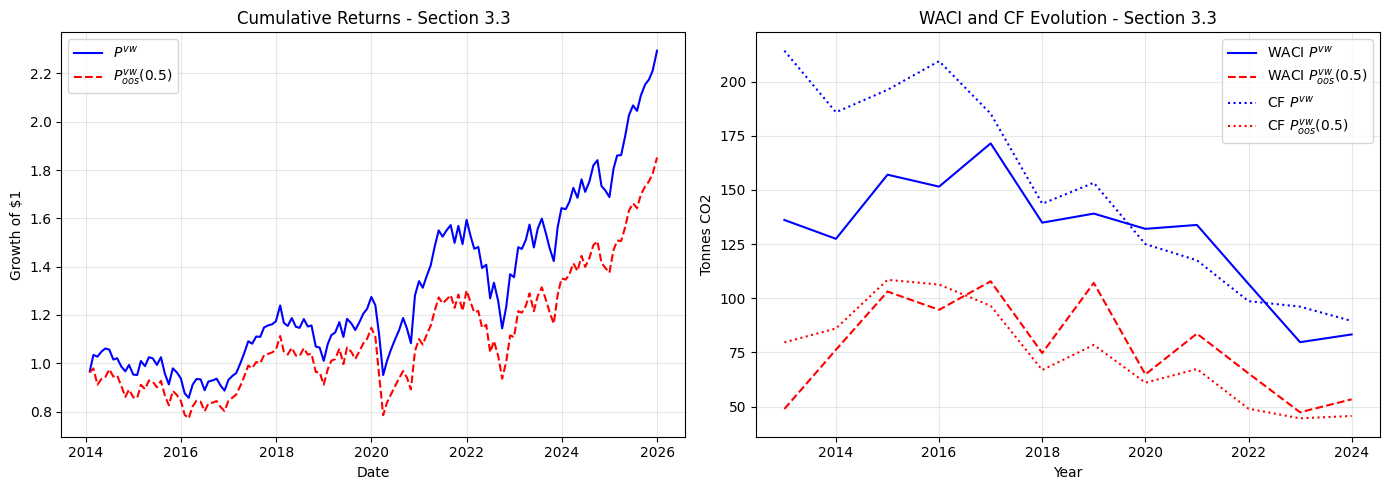

Plot saved!


In [55]:
# WACI and CF for P_vw_oos(0.5)

waci_vw05_dict, cf_vw05_dict = {}, {}

for y in range(START_REBAL_YEAR, END_REBAL_YEAR + 1):
    w = weights_vw05_dict[y]
    investable = w.index.tolist()

    ci_y  = CI.loc[investable, y] if y in CI.columns else pd.Series(np.nan, index=investable)
    em_y  = emissions.loc[investable, y] if y in emissions.columns else pd.Series(np.nan, index=investable)
    cap_y = mv_annual_clean.loc[investable, y] if y in mv_annual_clean.columns else pd.Series(np.nan, index=investable)

    valid_ci = ci_y.notna()
    waci_vw05_dict[y] = float((w[valid_ci] * ci_y[valid_ci]).sum()) if valid_ci.any() else np.nan

    valid_cf = em_y.notna() & cap_y.notna() & (cap_y > 0)
    cf_vw05_dict[y] = float((w[valid_cf] * em_y[valid_cf] / cap_y[valid_cf]).sum()) if valid_cf.any() else np.nan

waci_vw05 = pd.Series(waci_vw05_dict)
cf_vw05   = pd.Series(cf_vw05_dict)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative returns
cum_vw   = (1 + r_vw).cumprod()
cum_vw05 = (1 + r_vw05).cumprod()

axes[0].plot(cum_vw.index,   cum_vw,   label="$P^{vw}$",            color="blue")
axes[0].plot(cum_vw05.index, cum_vw05, label="$P^{vw}_{oos}(0.5)$", color="red", linestyle="--")
axes[0].set_title("Cumulative Returns - Section 3.3")
axes[0].set_ylabel("Growth of $1")
axes[0].set_xlabel("Date")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# WACI and CF evolution
axes[1].plot(waci_vw.index,   waci_vw,   label="WACI $P^{vw}$",            color="blue")
axes[1].plot(waci_vw05.index, waci_vw05, label="WACI $P^{vw}_{oos}(0.5)$", color="red",  linestyle="--")
axes[1].plot(cf_vw.index,     cf_vw,     label="CF $P^{vw}$",              color="blue", linestyle=":")
axes[1].plot(cf_vw05.index,   cf_vw05,   label="CF $P^{vw}_{oos}(0.5)$",   color="red",  linestyle=":")
axes[1].set_title("WACI and CF Evolution - Section 3.3")
axes[1].set_ylabel("Tonnes CO2")
axes[1].set_xlabel("Year")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot_section33.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved!")

=== Section 3.4 - Summary Statistics ===
                              P_mv_oos  P_mv_oos(0.5)    P_vw  P_vw_oos(0.5)
Annualized return               0.0467         0.0532  0.0819         0.0651
Annualized volatility           0.1377         0.1356  0.1581         0.1645
Annualized cumulative return    0.0378         0.0449  0.0716         0.0527
Sharpe ratio                    0.3393         0.3926  0.5178         0.3957
Minimum monthly return         -0.1200        -0.1143 -0.1530        -0.1785
Maximum monthly return          0.1424         0.1356  0.1828         0.1784


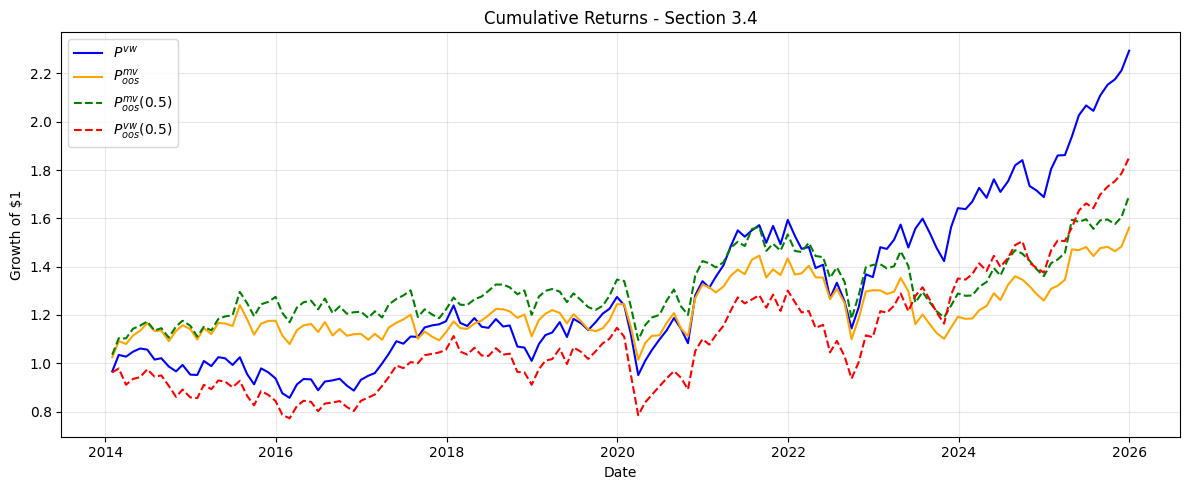

Plot saved!


In [56]:
# Section 3.4 - Compare P_mv, P_mv(0.5), P_vw, P_vw(0.5)
# Financial performance and carbon footprint trade-off

stats_34 = pd.DataFrame({
    "P_mv_oos":       annualized_stats(r_mv),
    "P_mv_oos(0.5)":  annualized_stats(r_mv05),
    "P_vw":           annualized_stats(r_vw),
    "P_vw_oos(0.5)":  annualized_stats(r_vw05),
})

print("=== Section 3.4 - Summary Statistics ===")
print(stats_34.round(4))

# Cumulative returns plot
fig, ax = plt.subplots(figsize=(12, 5))

cum_mv   = (1 + r_mv).cumprod()
cum_mv05 = (1 + r_mv05).cumprod()
cum_vw   = (1 + r_vw).cumprod()
cum_vw05 = (1 + r_vw05).cumprod()

ax.plot(cum_vw.index,   cum_vw,   label="$P^{vw}$",             color="blue")
ax.plot(cum_mv.index,   cum_mv,   label="$P^{mv}_{oos}$",       color="orange")
ax.plot(cum_mv05.index, cum_mv05, label="$P^{mv}_{oos}(0.5)$",  color="green",  linestyle="--")
ax.plot(cum_vw05.index, cum_vw05, label="$P^{vw}_{oos}(0.5)$",  color="red",    linestyle="--")
ax.set_title("Cumulative Returns - Section 3.4")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot_section34.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved!")

## Section 4 - Portfolio Allocation with a Net Zero Objective

In [57]:
# Section 4.1 - P_vw_oos(NZ)
# Minimize tracking error vs value-weighted portfolio
# with cumulative 10% annual CF reduction from 2013 baseline
# CF constraint: CF <= (1 - theta)^(Y - Y0 + 1) * CF_vw_Y0

theta    = 0.10
Y0       = 2013
CF_vw_Y0 = cf_vw[Y0]

print(f"CF value-weighted 2013 (baseline): {CF_vw_Y0:.4f}")
print("\nComputing P_vw_oos(NZ)...")

all_vwNZ, weights_vwNZ_dict = [], {}

for y in range(START_REBAL_YEAR, END_REBAL_YEAR + 1):
    investable = list(weights_dict[y].index)
    em_y  = emissions.loc[investable, y] if y in emissions.columns else pd.Series(np.nan, index=investable)
    cap_y = mv_annual_clean.loc[investable, y] if y in mv_annual_clean.columns else pd.Series(np.nan, index=investable)

    valid     = em_y.notna() & cap_y.notna() & (cap_y > 0)
    inv_valid = [i for i in investable if valid[i]]

    em_v, cap_v = em_y[inv_valid], cap_y[inv_valid]
    total_cap   = cap_v.sum()
    w_vw_arr    = (cap_v / total_cap).values

    # CF target decreases by 10% per year from 2013 baseline
    cf_target = (1 - theta) ** (y - Y0 + 1) * CF_vw_Y0

    dec_y     = get_december(y, returns_m.columns)
    end_pos   = returns_m.columns.get_loc(dec_y)
    start_pos = end_pos - ESTIMATION_MONTHS + 1
    window    = returns_m.loc[inv_valid, returns_m.columns[start_pos:end_pos+1]].T
    window    = window.replace([np.inf, -np.inf], np.nan)
    cov       = window.cov(ddof=0).to_numpy()

    w = tracking_error_carbon_constraint(cov, w_vw_arr, cf_target, em_v, cap_v)
    weights_vwNZ_dict[y] = pd.Series(w, index=inv_valid)

    rp, _ = compute_monthly_returns(returns_m, mv_m, y, inv_valid, w)
    all_vwNZ.append(rp)
    print(f"  {y}: CF_target={cf_target:.4f}, firms={len(inv_valid)}")

r_vwNZ = pd.concat(all_vwNZ).sort_index().loc["2014-01-31":"2025-12-31"]

print("\nSummary statistics - P_vw vs P_vw(NZ):")
stats_41 = pd.DataFrame({
    "P_vw":      annualized_stats(r_vw),
    "P_vw(NZ)":  annualized_stats(r_vwNZ),
})
print(stats_41.round(4))

CF value-weighted 2013 (baseline): 214.2432

Computing P_vw_oos(NZ)...
  2013: CF_target=192.8189, firms=469
  2014: CF_target=173.5370, firms=487
  2015: CF_target=156.1833, firms=505
  2016: CF_target=140.5650, firms=511
  2017: CF_target=126.5085, firms=524
  2018: CF_target=113.8576, firms=545
  2019: CF_target=102.4719, firms=572
  2020: CF_target=92.2247, firms=591
  2021: CF_target=83.0022, firms=600
  2022: CF_target=74.7020, firms=590
  2023: CF_target=67.2318, firms=575
  2024: CF_target=60.5086, firms=563

Summary statistics - P_vw vs P_vw(NZ):
                                P_vw  P_vw(NZ)
Annualized return             0.0819    0.0706
Annualized volatility         0.1581    0.1614
Annualized cumulative return  0.0716    0.0591
Sharpe ratio                  0.5178    0.4374
Minimum monthly return       -0.1530   -0.1593
Maximum monthly return        0.1828    0.1884


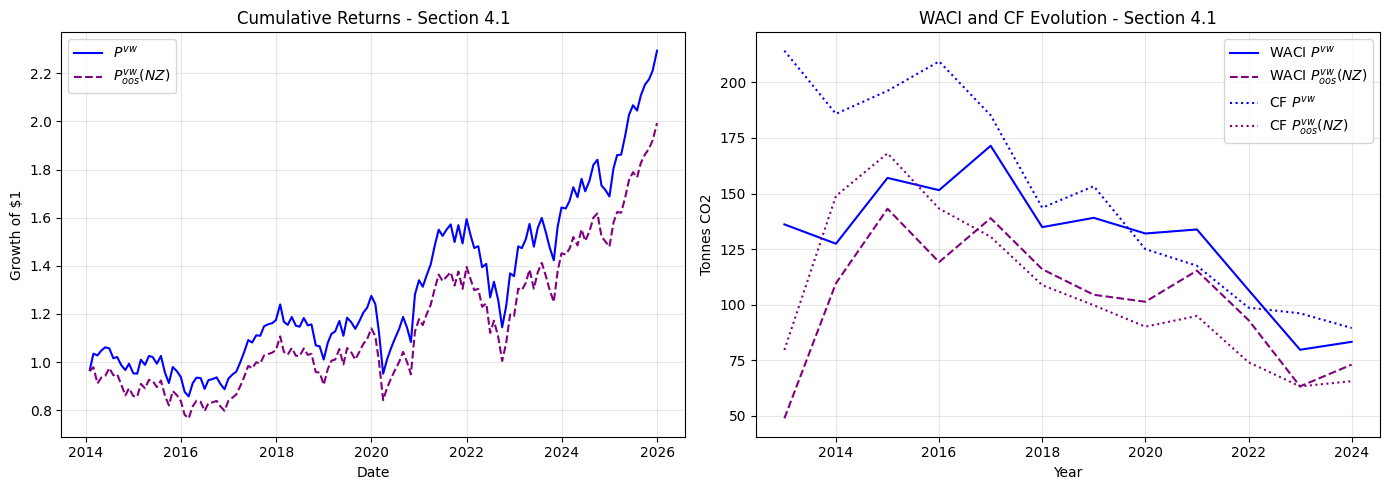

Plot saved!


In [58]:
# WACI and CF for P_vw_oos(NZ)

waci_vwNZ_dict, cf_vwNZ_dict = {}, {}

for y in range(START_REBAL_YEAR, END_REBAL_YEAR + 1):
    w = weights_vwNZ_dict[y]
    investable = w.index.tolist()

    ci_y  = CI.loc[investable, y] if y in CI.columns else pd.Series(np.nan, index=investable)
    em_y  = emissions.loc[investable, y] if y in emissions.columns else pd.Series(np.nan, index=investable)
    cap_y = mv_annual_clean.loc[investable, y] if y in mv_annual_clean.columns else pd.Series(np.nan, index=investable)

    valid_ci = ci_y.notna()
    waci_vwNZ_dict[y] = float((w[valid_ci] * ci_y[valid_ci]).sum()) if valid_ci.any() else np.nan

    valid_cf = em_y.notna() & cap_y.notna() & (cap_y > 0)
    cf_vwNZ_dict[y] = float((w[valid_cf] * em_y[valid_cf] / cap_y[valid_cf]).sum()) if valid_cf.any() else np.nan

waci_vwNZ = pd.Series(waci_vwNZ_dict)
cf_vwNZ   = pd.Series(cf_vwNZ_dict)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cum_vwNZ = (1 + r_vwNZ).cumprod()

axes[0].plot(cum_vw.index,   cum_vw,   label="$P^{vw}$",            color="blue")
axes[0].plot(cum_vwNZ.index, cum_vwNZ, label="$P^{vw}_{oos}(NZ)$",  color="purple", linestyle="--")
axes[0].set_title("Cumulative Returns - Section 4.1")
axes[0].set_ylabel("Growth of $1")
axes[0].set_xlabel("Date")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(waci_vw.index,   waci_vw,   label="WACI $P^{vw}$",            color="blue")
axes[1].plot(waci_vwNZ.index, waci_vwNZ, label="WACI $P^{vw}_{oos}(NZ)$",  color="purple", linestyle="--")
axes[1].plot(cf_vw.index,     cf_vw,     label="CF $P^{vw}$",              color="blue",   linestyle=":")
axes[1].plot(cf_vwNZ.index,   cf_vwNZ,   label="CF $P^{vw}_{oos}(NZ)$",    color="purple", linestyle=":")
axes[1].set_title("WACI and CF Evolution - Section 4.1")
axes[1].set_ylabel("Tonnes CO2")
axes[1].set_xlabel("Year")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot_section41.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved!")

=== Section 4.2 - Summary Statistics ===
                                P_vw  P_vw_oos(0.5)  P_vw_oos(NZ)
Annualized return             0.0819         0.0651        0.0706
Annualized volatility         0.1581         0.1645        0.1614
Annualized cumulative return  0.0716         0.0527        0.0591
Sharpe ratio                  0.5178         0.3957        0.4374
Minimum monthly return       -0.1530        -0.1785       -0.1593
Maximum monthly return        0.1828         0.1784        0.1884


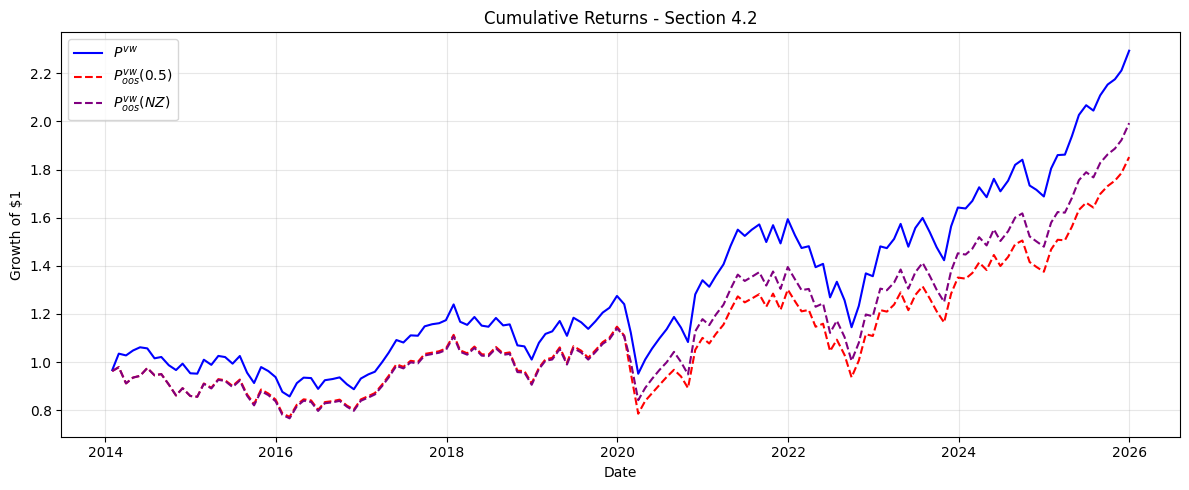

Plot saved!


In [59]:
# Section 4.2 - Compare P_vw, P_vw(0.5) and P_vw(NZ)
# Comment on the cost of constructing a net zero portfolio

stats_42 = pd.DataFrame({
    "P_vw":          annualized_stats(r_vw),
    "P_vw_oos(0.5)": annualized_stats(r_vw05),
    "P_vw_oos(NZ)":  annualized_stats(r_vwNZ),
})

print("=== Section 4.2 - Summary Statistics ===")
print(stats_42.round(4))

# Cumulative returns plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(cum_vw.index,   cum_vw,   label="$P^{vw}$",             color="blue")
ax.plot(cum_vw05.index, cum_vw05, label="$P^{vw}_{oos}(0.5)$",  color="red",    linestyle="--")
ax.plot(cum_vwNZ.index, cum_vwNZ, label="$P^{vw}_{oos}(NZ)$",   color="purple", linestyle="--")
ax.set_title("Cumulative Returns - Section 4.2")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plot_section42.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved!")